In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_validate, learning_curve
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import RandomizedSearchCV

In [54]:
file_path = "samples/dataset.xlsx"

df = pd.read_excel(file_path)

df.columns = df.columns.str.strip()
df = df.dropna(how="all").reset_index(drop=True)

numeric_cols = [
    "Volume",
    "Area",
    "MaxHeight",
    "CenterDiviation",
    "UsedCoilArea",
    "SensorTemp",
    "SensorValueRAW",
    "KT10valueMax",
    "KT10valueCenterDiviation",
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

if numeric_cols:
    df[numeric_cols] = df[numeric_cols].astype(str).map(
        lambda x: x.replace(",", ".") if isinstance(x, str) else x
    )
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

if "SensorId" in df.columns:
    df["SensorId"] = pd.to_numeric(df["SensorId"], errors="coerce").astype("Int64")

if "DateTime" in df.columns:
    df["DateTime"] = pd.to_datetime(df["DateTime"], format="%Y-%m-%d_%H-%M-%S", errors="coerce")

print(df.head())
print(df.info())

      Label            DateTime  SensorId   Volume     Area  MaxHeight  \
0  UL17.1.0 2026-03-12 13:56:15         5  12.9742  16.0051    1.23164   
1  UL17.1.0 2026-03-12 13:56:15         5  12.9742  16.0051    1.23164   
2  UL17.1.0 2026-03-12 13:56:15         5  12.9742  16.0051    1.23164   
3    G1.1.0 2026-03-13 09:33:58         6  32.2500  14.5093    3.23182   
4    G1.1.0 2026-03-13 09:33:58         6  32.2500  14.5093    3.23182   

   CenterDiviation  UsedCoilArea  SensorTemp  SensorValueRAW  KT10valueMax  
0         13.85000      0.569170        22.0         224.584           6.5  
1          2.77000      0.770751        22.0         286.584           6.5  
2          8.31000      0.687747        22.0         227.584           6.5  
3         14.86550      0.537549        19.0         295.870          15.6  
4          6.06901      0.644269        19.0         492.870          15.6  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 1

In [55]:
df.describe()

,DateTime,SensorId,Volume,Area,MaxHeight,CenterDiviation,UsedCoilArea,SensorTemp,SensorValueRAW,KT10valueMax
count,699,699.0,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,2026-03-21 19:00:41.834048256,5.519313,25.868623,15.417444,2.356228,10.082834,0.577126,20.250646,1003.601320,37.767828
min,2026-03-12 13:56:15,4.0,5.138910,5.384880,0.901440,2.770000,0.181818,18.000000,1.385050,0.030000
25%,2026-03-13 12:42:18,5.0,12.160200,9.872280,1.847840,6.162920,0.432806,20.000000,78.324100,1.900000
50%,2026-03-25 11:07:39,5.0,20.480900,13.761400,2.294260,8.310000,0.565217,20.500000,500.551000,17.400000
75%,2026-03-25 13:46:45,6.0,27.811700,17.276500,2.703760,14.865500,0.703557,20.500000,1155.590000,42.200000
max,2026-03-25 15:00:51,11.0,98.867000,36.946300,4.050300,25.168100,1.000000,22.433300,19953.900000,624.000000
std,NaN,0.67972,20.661675,7.831001,0.714266,4.956450,0.182384,0.756576,2366.694576,85.222082


In [56]:
corr_matrix = df[numeric_cols].corr()
corr_matrix["KT10valueMax"].sort_values(ascending=False)

KT10valueMax       1.000000
SensorValueRAW     0.985214
Volume             0.358031
Area               0.313391
UsedCoilArea       0.286110
MaxHeight          0.168793
CenterDiviation    0.053754
SensorTemp        -0.025260
Name: KT10valueMax, dtype: float64

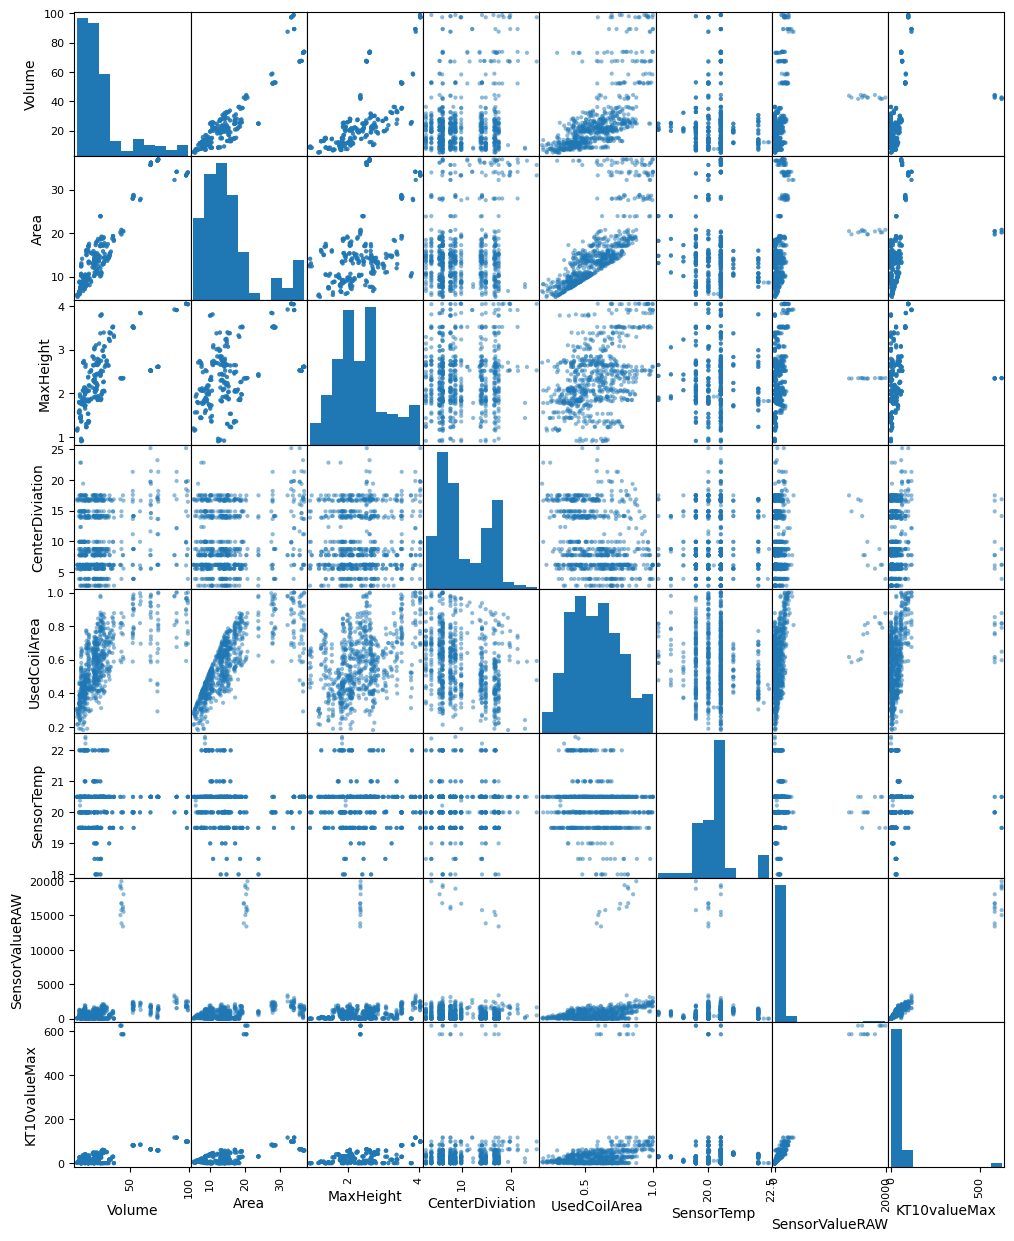

In [57]:
from pandas.plotting import scatter_matrix

scatter_matrix(df[numeric_cols], figsize=(12, 15))
plt.show()

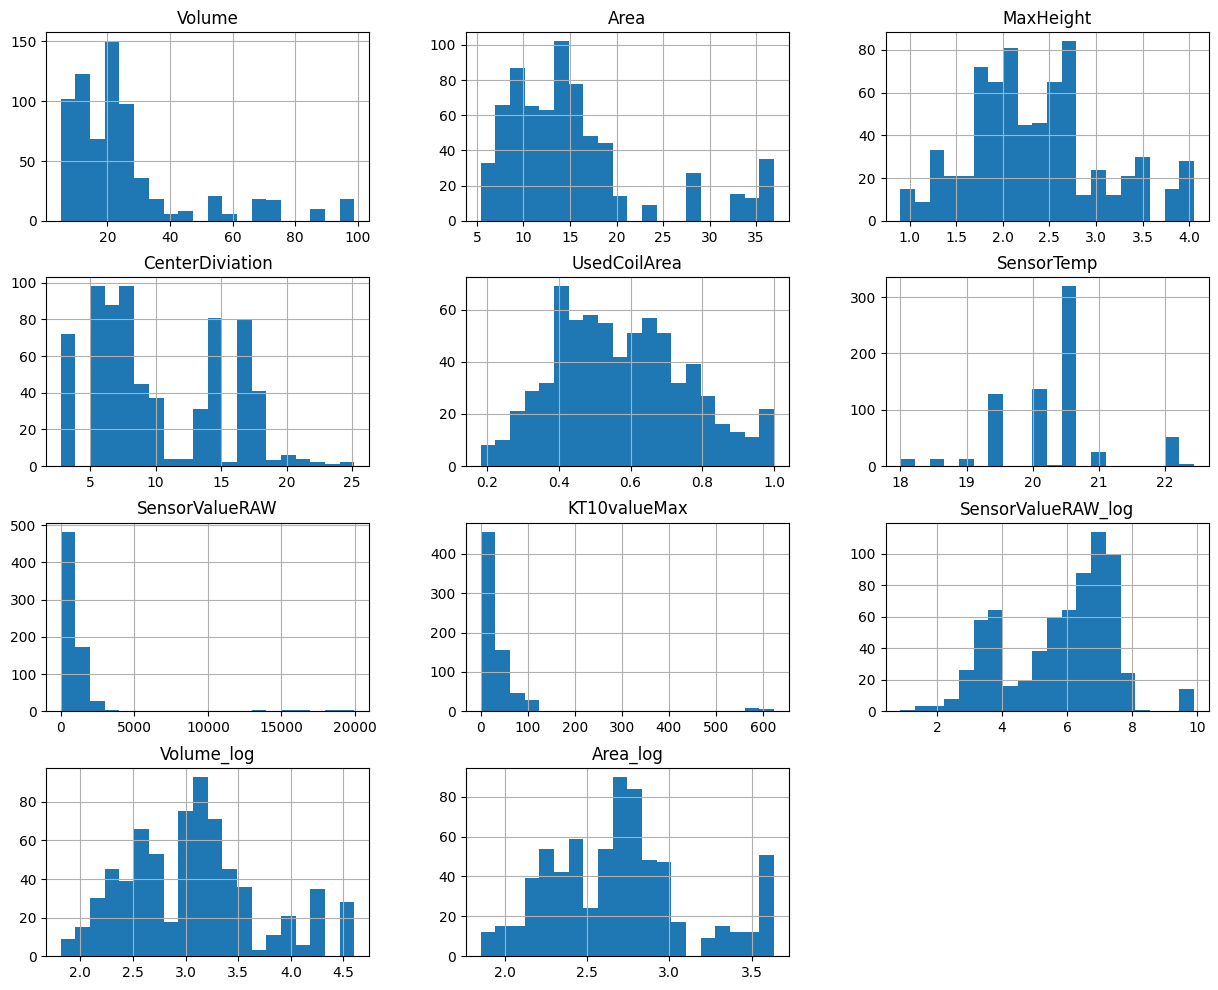

In [58]:
df_enhanced = df[numeric_cols].copy()

for col in ["SensorValueRAW", "Volume", "Area"]:
    if col in df_enhanced.columns:
        df_enhanced[f"{col}_log"] = np.log1p(df_enhanced[col].clip(lower=0))

df_enhanced.hist(bins=20, figsize=(15, 12), grid=True)
plt.show()

In [59]:
from sklearn.base import BaseEstimator, TransformerMixin

class LogFeaturesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        self.columns_ = [col for col in self.columns if col in X.columns]
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns_:
            X[col] = np.log1p(X[col].clip(lower=0))
        return X

R^2 per fold: [0.96378045 0.99472944 0.96395251 0.99850128 0.7228222  0.92531216
 0.93885635 0.88210902 0.699308   0.70991481]
RMSE per fold: [ 5.36906529 12.91130589  2.62809317  7.2492333  11.55791304 10.40902637
  5.29906811  5.72786896 20.33201493  8.3862765 ]

Overall Performance:
R^2  : 0.8799 ± 0.1154
RMSE: 8.9870 ± 4.8360


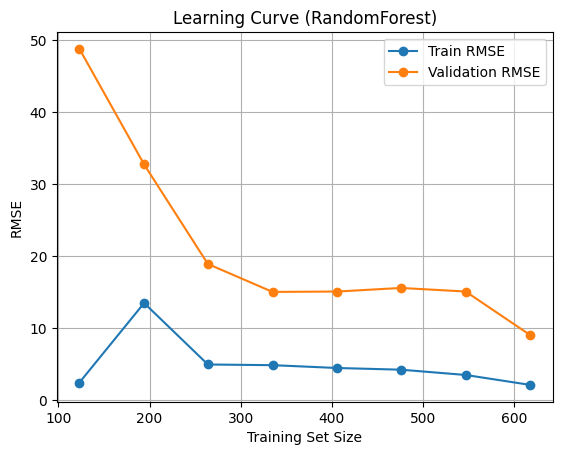

In [60]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", TransformedTargetRegressor(
        regressor=RandomForestRegressor(
            n_estimators=100,
            min_samples_split=5,
            min_samples_leaf=2,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

target_col = "KT10valueMax"

feature_cols = [
    "SensorId",
    "Volume",
    "Area",
    "MaxHeight",
    "CenterDiviation",
    "UsedCoilArea",
    "SensorTemp",
    "SensorValueRAW",
]

feature_cols = [col for col in feature_cols if col in df.columns]

model_df = df[["Label", target_col] + feature_cols].dropna(subset=[target_col]).copy()

X = model_df[feature_cols]
y = model_df[target_col]
groups = model_df["Label"]

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error"
}

kf = GroupKFold(n_splits=10, shuffle=True, random_state=42)
results = cross_validate(
    pipeline,
    X,
    y,
    cv=kf,
    groups=groups,
    scoring=scoring,
    n_jobs=-1
)

r2_scores = results["test_r2"]
rmse_scores = -results["test_rmse"]

print(f"R^2 per fold: {r2_scores}")
print(f"RMSE per fold: {rmse_scores}")

print("\nOverall Performance:")
print(f"R^2  : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

train_sizes = np.linspace(0.2, 1.0, 8)

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    groups=groups,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    train_sizes=train_sizes,
    n_jobs=-1,
    random_state=42
)

train_rmse = -train_scores
val_rmse = -val_scores

train_mean = train_rmse.mean(axis=1)
val_mean = val_rmse.mean(axis=1)

plt.figure()
plt.plot(train_sizes_abs, train_mean, marker="o", label="Train RMSE")
plt.plot(train_sizes_abs, val_mean, marker="o", label="Validation RMSE")

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Learning Curve (RandomForest)")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
param_distributions = {
    "model__regressor__n_estimators": [100, 200, 300, 500, 700],
    "model__regressor__max_depth": [3, 4, 5, 7, 10, None],
    "model__regressor__min_samples_split": [2, 5, 10, 15],
    "model__regressor__min_samples_leaf": [1, 2, 3, 5, 10],
    "model__regressor__max_features": [None, "sqrt", "log2"],
}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=100,
    cv=kf,
    scoring=scoring,
    n_jobs=-1,
    random_state=42,
    refit=False,
    return_train_score=False
)

random_search.fit(X, y, groups=groups)

results = pd.DataFrame(random_search.cv_results_)

results["mean_rmse"] = -results["mean_test_rmse"]
results["std_rmse"] = results["std_test_rmse"]
results["mean_r2"] = results["mean_test_r2"]

for lam in [0.0, 0.5, 1.0, 2.0]:
    results[f"selection_score_lam_{lam}"] = results["mean_rmse"] + lam * results["std_rmse"]

score_col = "selection_score_lam_1.0"
best_row = results.sort_values(score_col).iloc[0]

print("Best Parameters:")
print(best_row["params"])

print("\nBest Metrics:")
print(f"Mean RMSE: {best_row['mean_rmse']:.4f}")
print(f"Std RMSE : {best_row['std_rmse']:.4f}")
print(f"Mean R^2 : {best_row['mean_r2']:.4f}")
print(f"Selection score ({score_col}): {best_row[score_col]:.4f}")

display_cols = [
    "params",
    "mean_rmse",
    "std_rmse",
    "mean_r2",
    "selection_score_lam_0.0",
    "selection_score_lam_0.5",
    "selection_score_lam_1.0",
    "selection_score_lam_2.0",
]

top_results = results[display_cols].sort_values(score_col).head(10)
top_results

Best Parameters:
{'model__regressor__n_estimators': 100, 'model__regressor__min_samples_split': 5, 'model__regressor__min_samples_leaf': 2, 'model__regressor__max_features': None, 'model__regressor__max_depth': 10}

Best Metrics:
Mean RMSE: 8.9870
Std RMSE : 4.8360
Mean R^2 : 0.8799
Selection score (selection_score_lam_1.0): 13.8230


,params,mean_rmse,std_rmse,mean_r2,selection_score_lam_0.0,selection_score_lam_0.5,selection_score_lam_1.0,selection_score_lam_2.0
12,"{'model__regressor__n_estimators': 100, 'model...",8.986987,4.836010,0.879929,8.986987,11.404992,13.822996,18.659006
13,"{'model__regressor__n_estimators': 200, 'model...",9.286891,4.615450,0.871315,9.286891,11.594616,13.902341,18.517792
11,"{'model__regressor__n_estimators': 700, 'model...",9.655817,4.624709,0.861999,9.655817,11.968171,14.280526,18.905235
23,"{'model__regressor__n_estimators': 500, 'model...",9.707242,4.907878,0.871081,9.707242,12.161181,14.615120,19.522998
1,"{'model__regressor__n_estimators': 500, 'model...",9.763009,4.895334,0.869995,9.763009,12.210676,14.658343,19.553677
81,"{'model__regressor__n_estimators': 500, 'model...",9.763009,4.895334,0.869995,9.763009,12.210676,14.658343,19.553677
37,"{'model__regressor__n_estimators': 700, 'model...",10.612944,4.517108,0.833567,10.612944,12.871498,15.130052,19.647160
52,"{'model__regressor__n_estimators': 100, 'model...",10.513612,4.660964,0.837693,10.513612,12.844093,15.174575,19.835539
87,"{'model__regressor__n_estimators': 100, 'model...",10.079562,5.174148,0.861666,10.079562,12.666636,15.253710,20.427858
90,"{'model__regressor__n_estimators': 700, 'model...",10.886212,4.840643,0.830415,10.886212,13.306533,15.726854,20.567497
